## GNN + Conformal Prediction for Cancer Drug Response Prediction

### This notebook implements a Graph Neural Network for predicting cancer drug response (IC50 values) with Conformal Prediction for uncertainty quantification.

In [1]:
# !pip install torch-geometric PyTDC rdkit-pypi scikit-learn matplotlib seaborn tqdm

In [2]:
# !pip install PyTDC --upgrade

### Imports and setup

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import copy

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# PyTorch Geometric imports
from torch_geometric.data import Data, Dataset
try:
    from torch_geometric.loader import DataLoader  # PyG >= 2.0
except ImportError:
    from torch_geometric.data import DataLoader    # PyG < 2.0
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

# RDKit for molecular processing
from rdkit import Chem

# Scikit-learn for metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA L4
Memory: 23.7 GB


### Data loading

In [4]:
print("\n" + "="*60)
print("LOADING GDSC DATA")
print("="*60)

def load_gdsc_from_tdc():
    """
    Load GDSC dataset using the correct TDC API.
    Returns DataFrame with Drug (SMILES), Cell Line, and Y (IC50).
    """
    try:
        from tdc.multi_pred import DrugRes
        
        print("Loading GDSC1 from TDC...")
        data = DrugRes(name='GDSC1')
        df = data.get_data()
        
        print(f"✓ Successfully loaded GDSC1!")
        print(f"  Shape: {df.shape}")
        print(f"  Columns: {df.columns.tolist()}")
        
        # TDC returns columns: Drug_ID, Drug, Cell Line_ID, Cell Line, Y
        # - Drug_ID: drug name
        # - Drug: SMILES string
        # - Cell Line_ID: cell line name  
        # - Cell Line: gene expression vector (we'll use this or create embeddings)
        # - Y: log IC50 value
        
        return df, 'TDC_GDSC1'
        
    except ImportError as e:
        print(f"TDC import failed: {e}")
        print("Try: pip install PyTDC")
        return None, None
    except Exception as e:
        print(f"TDC loading failed: {e}")
        return None, None

# Placeholder function for future implementation if needed
# def load_gdsc_from_cancerrxgene():
#     """
#     Alternative: Download directly from CancerRxGene (official GDSC source).
#     Note: This requires more data processing.
#     """
#     try:
#         import requests
#         import io
        
#         print("Attempting to load from CancerRxGene...")
        
#         # GDSC fitted dose-response data
#         # May need to download manually from: https://www.cancerrxgene.org/downloads/bulk_download
#         # The direct API access may require registration
        
#         print("Note: CancerRxGene requires manual download or API registration.")
#         print("Visit: https://www.cancerrxgene.org/downloads/bulk_download")
#         return None, None
        
#     except Exception as e:
#         print(f"CancerRxGene loading failed: {e}")
#         return None, None


# Try loading methods in order of preference
df = None
data_source = None

# Method 1: TDC 
df, data_source = load_gdsc_from_tdc()

# Method 2: If TDC fails...
if df is None:
    print("\n" + "="*60)
    print("MANUAL INSTALLATION REQUIRED")
    print("="*60)
    print("""
The automatic download failed. Please try:

1. Install/update PyTDC:
   !pip install PyTDC --upgrade

2. Then restart the runtime and run this cell again.

3. If that fails, can download GDSC data manually from:
   - https://www.cancerrxgene.org/downloads/bulk_download
   - Select 'Drug sensitivity data' -> 'Fitted data'
   
4. Or use the curated synthetic dataset (for testing only):
""")
    
    # Ask user if they want to proceed with synthetic data
    use_synthetic = True  # Set to False to stop execution
    
    if use_synthetic:
        print("Falling back to curated synthetic dataset...")
        print("  WARNING: Results will NOT be scientifically meaningful!")
        data_source = 'synthetic_curated'


# Validate and display data info
if df is not None:
    print(f"\n{'='*60}")
    print("DATA LOADED SUCCESSFULLY")
    print(f"{'='*60}")
    print(f"Source: {data_source}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    # Standardize column names for compatibility
    column_mapping = {
        'Drug_ID': 'Drug_ID',
        'Drug': 'Drug',  # SMILES
        'Cell Line_ID': 'Cell Line_ID',
        'Cell Line': 'Cell Line',  # Gene expression (if available)
        'Y': 'Y'  # IC50
    }
    
    # Check for required columns
    required = ['Drug_ID', 'Drug', 'Cell Line_ID', 'Y']
    missing = [col for col in required if col not in df.columns]
    
    if missing:
        print(f"  Missing columns: {missing}")
        # Try to fix common naming issues
        if 'Drug_ID' not in df.columns and 'drug_id' in df.columns:
            df = df.rename(columns={'drug_id': 'Drug_ID'})
        if 'Cell Line_ID' not in df.columns and 'cell_line_id' in df.columns:
            df = df.rename(columns={'cell_line_id': 'Cell Line_ID'})
    
    print(f"\nDataset Statistics:")
    print(f"  Unique drugs: {df['Drug_ID'].nunique()}")
    print(f"  Unique cell lines: {df['Cell Line_ID'].nunique()}")
    print(f"  Y (log IC50) range: [{df['Y'].min():.2f}, {df['Y'].max():.2f}]")
    print(f"\nSample data:")
    print(df.head())
else:
    raise RuntimeError("Failed to load GDSC data. Please check installation.")


LOADING GDSC DATA
Found local copy...
Loading...
Loading GDSC1 from TDC...
Done!
✓ Successfully loaded GDSC1!
  Shape: (177310, 5)
  Columns: ['Drug_ID', 'Drug', 'Cell Line_ID', 'Cell Line', 'Y']

DATA LOADED SUCCESSFULLY
Source: TDC_GDSC1
Shape: (177310, 5)
Columns: ['Drug_ID', 'Drug', 'Cell Line_ID', 'Cell Line', 'Y']

Dataset Statistics:
  Unique drugs: 208
  Unique cell lines: 958
  Y (log IC50) range: [-9.93, 12.36]

Sample data:
     Drug_ID                                               Drug Cell Line_ID  \
0  Erlotinib  COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...       MC-CAR   
1  Erlotinib  COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...          ES3   
2  Erlotinib  COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...          ES5   
3  Erlotinib  COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...          ES7   
4  Erlotinib  COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...        EW-11   

                                           Cell Line         Y  
0  [3.23827250

### Exploratory data analysis


EXPLORATORY DATA ANALYSIS

1. Analyzing target variable (IC50) distribution...


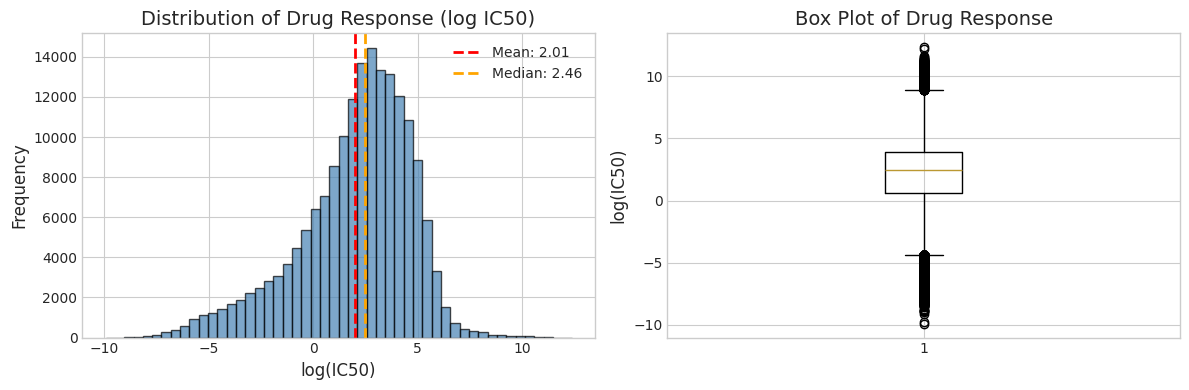

  IC50 Statistics:
    Mean: 2.0071
    Std:  2.7147
    Min:  -9.9334
    Max:  12.3591

2. Dataset composition...


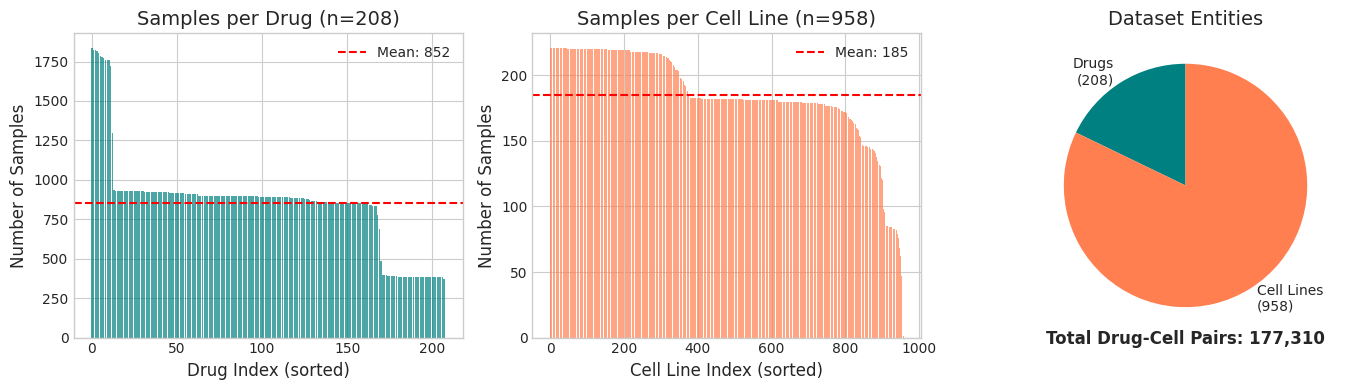


3. Top drugs and cell lines...


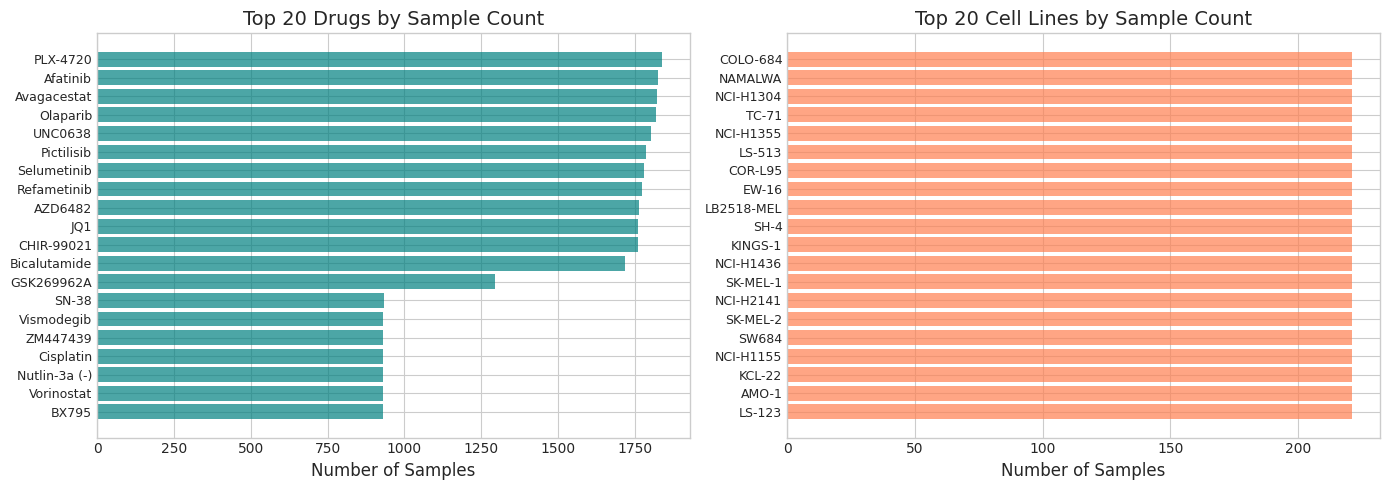


4. IC50 distribution by drug...


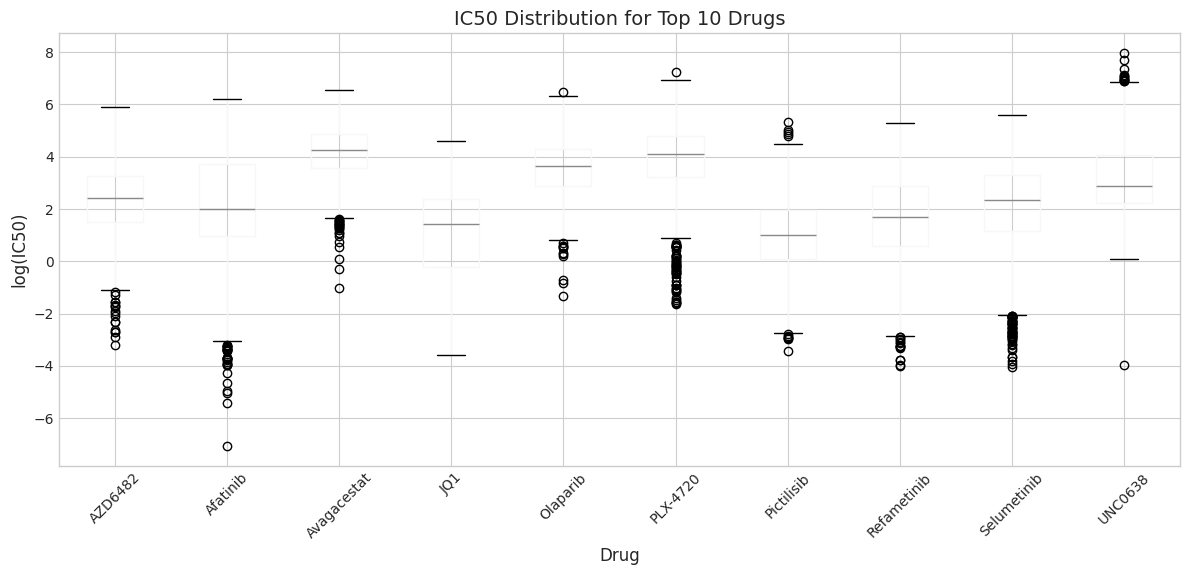


5. Creating drug-cell line sensitivity heatmap (subset)...


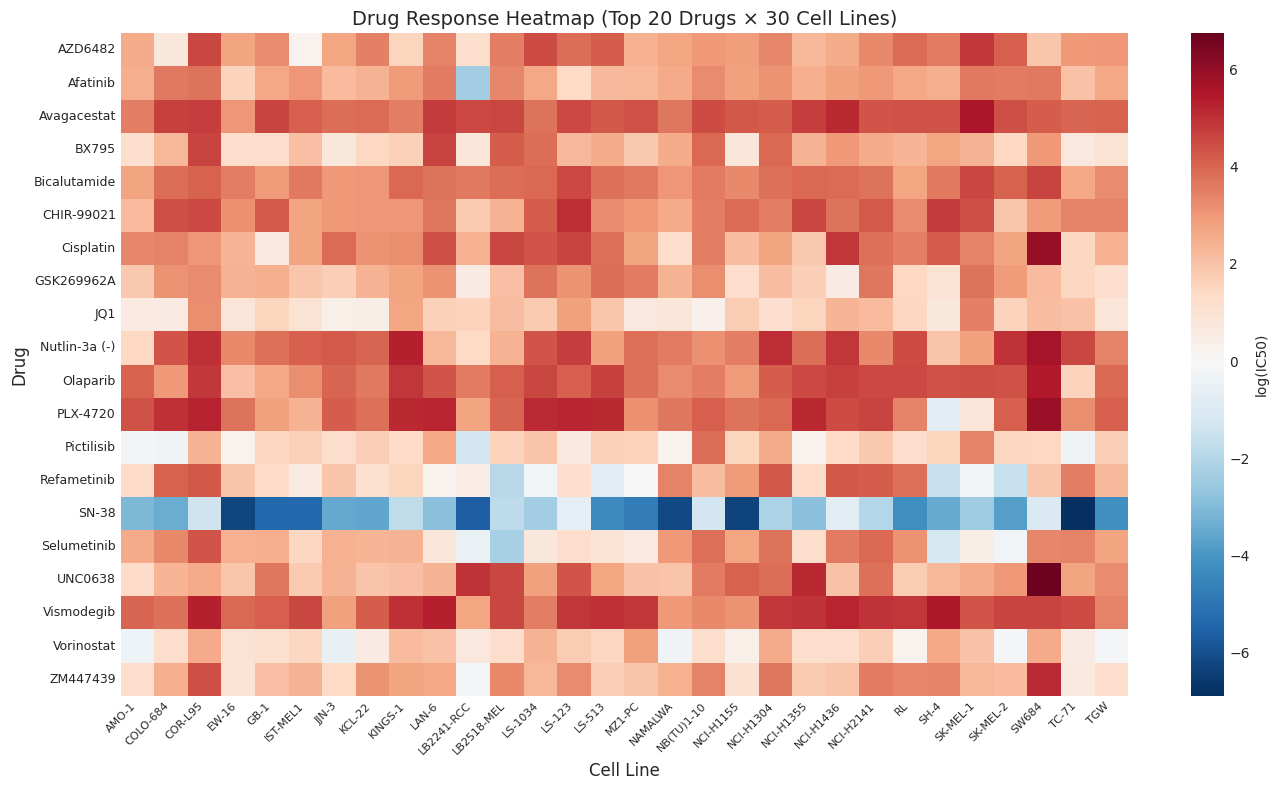


6. Missing value analysis...
  Total possible drug-cell pairs: 199,264
  Actual tested pairs: 177,310
  Coverage: 88.98%


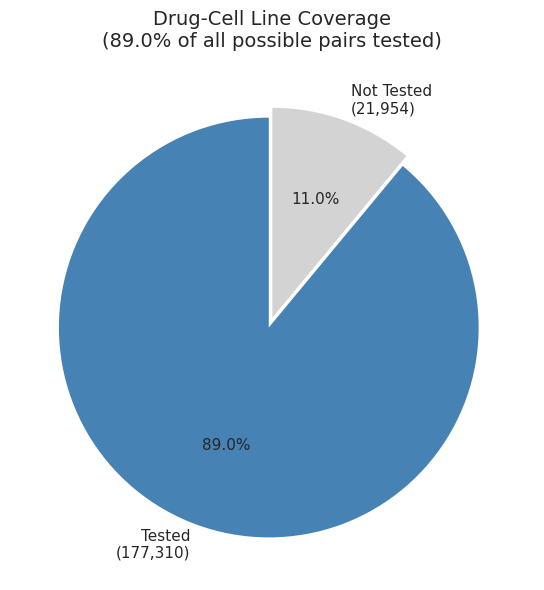


7. Gene expression overview...


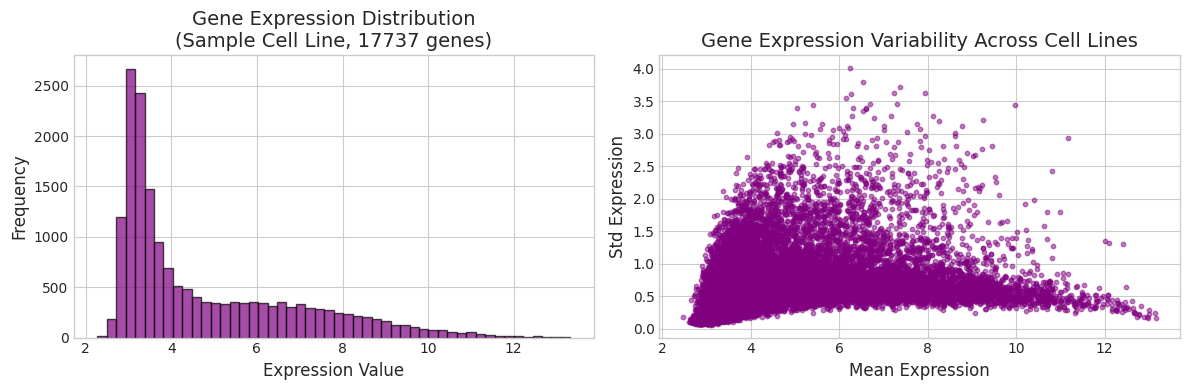

  Number of genes: 17737
  Expression range: [2.27, 13.32]

8. Summary statistics...

                      Metric   Value
               Total Samples 177,310
                Unique Drugs     208
           Unique Cell Lines     958
     Samples per Drug (mean)   852.5
      Samples per Drug (std)   305.1
Samples per Cell Line (mean)   185.1
 Samples per Cell Line (std)    35.9
                   IC50 Mean  2.0071
                    IC50 Std  2.7147
                    IC50 Min -9.9334
                    IC50 Max 12.3591
                Coverage (%)   88.98

EDA COMPLETE!
Figures saved to 'figures/' directory:
  - eda_ic50_distribution.png
  - eda_dataset_composition.png
  - eda_top_entities.png
  - eda_ic50_by_drug.png
  - eda_sensitivity_heatmap.png
  - eda_coverage.png
  - eda_gene_expression.png
  - eda_summary_stats.csv


In [5]:
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Create output directories
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)
fig_dir = 'figures'
results_dir = 'results'

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1. Distribution of IC50 Values (Target Variable)
print("\n1. Analyzing target variable (IC50) distribution...")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax1 = axes[0]
ax1.hist(df['Y'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df['Y'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {df["Y"].mean():.2f}')
ax1.axvline(df['Y'].median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {df["Y"].median():.2f}')
ax1.set_xlabel('log(IC50)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Drug Response (log IC50)', fontsize=14)
ax1.legend()

# Box plot
ax2 = axes[1]
ax2.boxplot(df['Y'], vert=True)
ax2.set_ylabel('log(IC50)', fontsize=12)
ax2.set_title('Box Plot of Drug Response', fontsize=14)

plt.tight_layout()
plt.savefig(f'{fig_dir}/eda_ic50_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  IC50 Statistics:")
print(f"    Mean: {df['Y'].mean():.4f}")
print(f"    Std:  {df['Y'].std():.4f}")
print(f"    Min:  {df['Y'].min():.4f}")
print(f"    Max:  {df['Y'].max():.4f}")


# 2. Dataset Composition Overview
print("\n2. Dataset composition...")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Samples per drug
samples_per_drug = df.groupby('Drug_ID').size().sort_values(ascending=False)
ax1 = axes[0]
ax1.bar(range(len(samples_per_drug)), samples_per_drug.values, color='teal', alpha=0.7)
ax1.set_xlabel('Drug Index (sorted)', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_title(f'Samples per Drug (n={len(samples_per_drug)})', fontsize=14)
ax1.axhline(samples_per_drug.mean(), color='red', linestyle='--', 
            label=f'Mean: {samples_per_drug.mean():.0f}')
ax1.legend()

# Samples per cell line
samples_per_cell = df.groupby('Cell Line_ID').size().sort_values(ascending=False)
ax2 = axes[1]
ax2.bar(range(len(samples_per_cell)), samples_per_cell.values, color='coral', alpha=0.7)
ax2.set_xlabel('Cell Line Index (sorted)', fontsize=12)
ax2.set_ylabel('Number of Samples', fontsize=12)
ax2.set_title(f'Samples per Cell Line (n={len(samples_per_cell)})', fontsize=14)
ax2.axhline(samples_per_cell.mean(), color='red', linestyle='--',
            label=f'Mean: {samples_per_cell.mean():.0f}')
ax2.legend()

# Summary pie chart
ax3 = axes[2]
summary_data = [len(samples_per_drug), len(samples_per_cell)]
labels = [f'Drugs\n({len(samples_per_drug)})', f'Cell Lines\n({len(samples_per_cell)})']
colors = ['teal', 'coral']
ax3.pie(summary_data, labels=labels, colors=colors, autopct='', startangle=90)
ax3.set_title('Dataset Entities', fontsize=14)

# Add text annotation
total_pairs = len(df)
ax3.text(0, -1.3, f'Total Drug-Cell Pairs: {total_pairs:,}', 
         ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{fig_dir}/eda_dataset_composition.png', dpi=150, bbox_inches='tight')
plt.show()


# 3. Top Drugs and Cell Lines by Sample Count
print("\n3. Top drugs and cell lines...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 drugs
top_drugs = samples_per_drug.head(20)
ax1 = axes[0]
bars1 = ax1.barh(range(len(top_drugs)), top_drugs.values, color='teal', alpha=0.7)
ax1.set_yticks(range(len(top_drugs)))
ax1.set_yticklabels(top_drugs.index, fontsize=9)
ax1.set_xlabel('Number of Samples', fontsize=12)
ax1.set_title('Top 20 Drugs by Sample Count', fontsize=14)
ax1.invert_yaxis()

# Top 20 cell lines
top_cells = samples_per_cell.head(20)
ax2 = axes[1]
bars2 = ax2.barh(range(len(top_cells)), top_cells.values, color='coral', alpha=0.7)
ax2.set_yticks(range(len(top_cells)))
ax2.set_yticklabels(top_cells.index, fontsize=9)
ax2.set_xlabel('Number of Samples', fontsize=12)
ax2.set_title('Top 20 Cell Lines by Sample Count', fontsize=14)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(f'{fig_dir}/eda_top_entities.png', dpi=150, bbox_inches='tight')
plt.show()


# 4. IC50 Distribution by Drug (Top Drugs)
print("\n4. IC50 distribution by drug...")

top_10_drugs = samples_per_drug.head(10).index.tolist()
df_top_drugs = df[df['Drug_ID'].isin(top_10_drugs)]

fig, ax = plt.subplots(figsize=(12, 6))
df_top_drugs.boxplot(column='Y', by='Drug_ID', ax=ax, rot=45)
ax.set_xlabel('Drug', fontsize=12)
ax.set_ylabel('log(IC50)', fontsize=12)
ax.set_title('IC50 Distribution for Top 10 Drugs', fontsize=14)
plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.savefig(f'{fig_dir}/eda_ic50_by_drug.png', dpi=150, bbox_inches='tight')
plt.show()


# 5. Drug Sensitivity Heatmap (Subset)
print("\n5. Creating drug-cell line sensitivity heatmap (subset)...")

# Select top drugs and cell lines for visualization
n_drugs_heatmap = 20
n_cells_heatmap = 30

top_drugs_hm = samples_per_drug.head(n_drugs_heatmap).index.tolist()
top_cells_hm = samples_per_cell.head(n_cells_heatmap).index.tolist()

# Create pivot table
df_subset = df[df['Drug_ID'].isin(top_drugs_hm) & df['Cell Line_ID'].isin(top_cells_hm)]
pivot_table = df_subset.pivot_table(values='Y', index='Drug_ID', columns='Cell Line_ID', aggfunc='mean')

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_table, cmap='RdBu_r', center=0, ax=ax,
            xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'log(IC50)'})
ax.set_xlabel('Cell Line', fontsize=12)
ax.set_ylabel('Drug', fontsize=12)
ax.set_title(f'Drug Response Heatmap (Top {n_drugs_heatmap} Drugs × {n_cells_heatmap} Cell Lines)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f'{fig_dir}/eda_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


# 6. Missing Value Analysis
print("\n6. Missing value analysis...")

# Check coverage (how many drug-cell pairs are tested)
total_possible = len(samples_per_drug) * len(samples_per_cell)
actual_pairs = len(df)
coverage = actual_pairs / total_possible * 100

print(f"  Total possible drug-cell pairs: {total_possible:,}")
print(f"  Actual tested pairs: {actual_pairs:,}")
print(f"  Coverage: {coverage:.2f}%")

fig, ax = plt.subplots(figsize=(6, 6))
sizes = [actual_pairs, total_possible - actual_pairs]
labels = [f'Tested\n({actual_pairs:,})', f'Not Tested\n({total_possible - actual_pairs:,})']
colors = ['steelblue', 'lightgray']
explode = (0.05, 0)
ax.pie(sizes, labels=labels, colors=colors, explode=explode,
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title(f'Drug-Cell Line Coverage\n({coverage:.1f}% of all possible pairs tested)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{fig_dir}/eda_coverage.png', dpi=150, bbox_inches='tight')
plt.show()


# 7. Gene Expression Overview (if available)
print("\n7. Gene expression overview...")

# Check if gene expression data is available
if 'Cell Line' in df.columns:
    # Get sample gene expression
    sample_expr = df['Cell Line'].iloc[0]
    
    if isinstance(sample_expr, (list, np.ndarray)):
        sample_expr = np.array(sample_expr)
        n_genes = len(sample_expr)
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Distribution of expression values (single cell line)
        ax1 = axes[0]
        ax1.hist(sample_expr, bins=50, edgecolor='black', alpha=0.7, color='purple')
        ax1.set_xlabel('Expression Value', fontsize=12)
        ax1.set_ylabel('Frequency', fontsize=12)
        ax1.set_title(f'Gene Expression Distribution\n(Sample Cell Line, {n_genes} genes)', fontsize=14)
        
        # Get multiple cell lines and show expression variability
        ax2 = axes[1]
        n_sample_cells = min(50, len(df['Cell Line_ID'].unique()))
        sample_cells = df.groupby('Cell Line_ID')['Cell Line'].first().head(n_sample_cells)
        expr_matrix = np.array([np.array(x) for x in sample_cells.values])
        
        # Mean expression per gene across cell lines
        mean_expr = expr_matrix.mean(axis=0)
        std_expr = expr_matrix.std(axis=0)
        
        ax2.scatter(mean_expr, std_expr, alpha=0.5, s=10, c='purple')
        ax2.set_xlabel('Mean Expression', fontsize=12)
        ax2.set_ylabel('Std Expression', fontsize=12)
        ax2.set_title('Gene Expression Variability Across Cell Lines', fontsize=14)
        
        plt.tight_layout()
        plt.savefig(f'{fig_dir}/eda_gene_expression.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"  Number of genes: {n_genes}")
        print(f"  Expression range: [{sample_expr.min():.2f}, {sample_expr.max():.2f}]")
    else:
        print("  Gene expression data format not recognized.")
else:
    print("  Gene expression column not found in dataset.")


# 8. Summary Statistics Table
print("\n8. Summary statistics...")

summary_stats = pd.DataFrame({
    'Metric': [
        'Total Samples',
        'Unique Drugs',
        'Unique Cell Lines',
        'Samples per Drug (mean)',
        'Samples per Drug (std)',
        'Samples per Cell Line (mean)',
        'Samples per Cell Line (std)',
        'IC50 Mean',
        'IC50 Std',
        'IC50 Min',
        'IC50 Max',
        'Coverage (%)'
    ],
    'Value': [
        f'{len(df):,}',
        f'{len(samples_per_drug)}',
        f'{len(samples_per_cell)}',
        f'{samples_per_drug.mean():.1f}',
        f'{samples_per_drug.std():.1f}',
        f'{samples_per_cell.mean():.1f}',
        f'{samples_per_cell.std():.1f}',
        f'{df["Y"].mean():.4f}',
        f'{df["Y"].std():.4f}',
        f'{df["Y"].min():.4f}',
        f'{df["Y"].max():.4f}',
        f'{coverage:.2f}'
    ]
})

print("\n" + summary_stats.to_string(index=False))

# Save summary
summary_stats.to_csv(f'{fig_dir}/eda_summary_stats.csv', index=False)

print(f"\n{'='*60}")
print("EDA COMPLETE!")
print(f"{'='*60}")
print(f"Figures saved to '{fig_dir}/' directory:")
print(f"  - eda_ic50_distribution.png")
print(f"  - eda_dataset_composition.png")
print(f"  - eda_top_entities.png")
print(f"  - eda_ic50_by_drug.png")
print(f"  - eda_sensitivity_heatmap.png")
print(f"  - eda_coverage.png")
print(f"  - eda_gene_expression.png")
print(f"  - eda_summary_stats.csv")

### Molecular featurization

In [6]:
def get_atom_features(atom):
    """
    Extract features for a single atom.
    Returns a feature vector of length 69.
      - Atom type one-hot: 44
      - Degree one-hot: 11
      - Formal charge one-hot: 5
      - Hybridization one-hot: 7
      - Is aromatic: 1
      - Normalized num Hs: 1
    """
    # Atom type (one-hot, 44 possible elements)
    atom_types = ['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg', 
                  'Na', 'Ca', 'Fe', 'As', 'Al', 'I', 'B', 'V', 'K', 'Tl',
                  'Yb', 'Sb', 'Sn', 'Ag', 'Pd', 'Co', 'Se', 'Ti', 'Zn', 'H',
                  'Li', 'Ge', 'Cu', 'Au', 'Ni', 'Cd', 'In', 'Mn', 'Zr', 'Cr',
                  'Pt', 'Hg', 'Pb', 'Other']
    
    atom_symbol = atom.GetSymbol()
    atom_type_encoding = [0] * len(atom_types)
    if atom_symbol in atom_types:
        atom_type_encoding[atom_types.index(atom_symbol)] = 1
    else:
        atom_type_encoding[-1] = 1  # 'Other'
    
    # Degree (one-hot, 0-10)
    degree = min(atom.GetDegree(), 10)
    degree_encoding = [0] * 11
    degree_encoding[degree] = 1
    
    # Formal charge (one-hot, -2 to 2)
    formal_charge = max(-2, min(atom.GetFormalCharge(), 2)) + 2
    charge_encoding = [0] * 5
    charge_encoding[formal_charge] = 1
    
    # Hybridization (one-hot)
    hybridization_types = [
        Chem.rdchem.HybridizationType.S,
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2,
    ]
    hybridization = atom.GetHybridization()
    hybridization_encoding = [0] * (len(hybridization_types) + 1)
    if hybridization in hybridization_types:
        hybridization_encoding[hybridization_types.index(hybridization)] = 1
    else:
        hybridization_encoding[-1] = 1
    
    # Additional features
    is_aromatic = [1 if atom.GetIsAromatic() else 0]
    num_hs = [min(atom.GetTotalNumHs(), 4) / 4.0]  # Normalized
    
    # Combine all features
    features = (atom_type_encoding + degree_encoding + charge_encoding + 
                hybridization_encoding + is_aromatic + num_hs)
    
    return features


def smiles_to_graph(smiles):
    """
    Convert SMILES string to PyTorch Geometric Data object.
    Returns None if conversion fails.
    """
    if not isinstance(smiles, str) or len(smiles) == 0:
        return None
        
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        # Check if molecule has atoms
        if mol.GetNumAtoms() == 0:
            return None
        
        # Get atom features
        atom_features = []
        for atom in mol.GetAtoms():
            atom_features.append(get_atom_features(atom))
        
        x = torch.tensor(atom_features, dtype=torch.float)
        
        # Get edge indices (bonds)
        edge_indices = []
        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            edge_indices.append([i, j])
            edge_indices.append([j, i])
        
        if len(edge_indices) == 0:
            # Single atom molecule - add self-loop
            edge_indices = [[0, 0]]
        
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        
        return Data(x=x, edge_index=edge_index)
    
    except Exception as e:
        # Silently return None for any parsing errors
        return None

# Process all unique drugs
print("Converting SMILES to molecular graphs...")
# Get drug SMILES mapping (Drug_ID -> SMILES)
drug_smiles = df[['Drug_ID', 'Drug']].drop_duplicates()
print(f"Unique drug entries: {len(drug_smiles)}")

# Convert SMILES to graphs
drug_to_graph = {}
failed_drugs = []

for idx, row in tqdm(drug_smiles.iterrows(), total=len(drug_smiles), desc="Processing drugs"):
    drug_id = row['Drug_ID']
    smiles = row['Drug']
    
    graph = smiles_to_graph(smiles)
    if graph is not None:
        drug_to_graph[drug_id] = graph
    else:
        failed_drugs.append(drug_id)

print(f"\nSuccessfully converted: {len(drug_to_graph)} drugs")
print(f"Failed conversions: {len(failed_drugs)}")
if failed_drugs:
    print(f"Failed drugs: {failed_drugs[:5]}...")  # Show first 5

Converting SMILES to molecular graphs...
Unique drug entries: 208
Processing drugs: 100%|██████████| 208/208 [00:00<00:00, 1416.01it/s]
Successfully converted: 208 drugs
Failed conversions: 0



### Cell line feature processing

In [7]:
print("\n" + "="*60)
print("PROCESSING CELL LINE GENE EXPRESSION FEATURES")
print("="*60)

# Extract gene expression features for each cell line
# The 'Cell Line' column contains gene expression vectors

# Get unique cell lines with their expression profiles
cell_line_data = df.groupby('Cell Line_ID')['Cell Line'].first().reset_index()

# Convert to numpy array
cell_line_ids = cell_line_data['Cell Line_ID'].values
gene_expressions = np.array([np.array(x) for x in cell_line_data['Cell Line'].values])

print(f"Number of cell lines: {len(cell_line_ids)}")
print(f"Gene expression shape: {gene_expressions.shape}")
print(f"  - {gene_expressions.shape[0]} cell lines")
print(f"  - {gene_expressions.shape[1]} genes per cell line")

# Normalize gene expression features (important for training stability)
gene_scaler = StandardScaler()
gene_expressions_normalized = gene_scaler.fit_transform(gene_expressions)

print(f"\nGene expression stats (after normalization):")
print(f"  Mean: {gene_expressions_normalized.mean():.4f}")
print(f"  Std:  {gene_expressions_normalized.std():.4f}")

# Create mappings
cell_line_to_idx = {cl: idx for idx, cl in enumerate(cell_line_ids)}
n_cell_lines = len(cell_line_ids)
n_genes = gene_expressions_normalized.shape[1]

# Store as tensor for easy lookup
gene_expression_tensor = torch.tensor(gene_expressions_normalized, dtype=torch.float32)

print(f"\n✓ Cell line features ready:")
print(f"  - cell_line_to_idx: maps cell line name -> index")
print(f"  - gene_expression_tensor: shape {gene_expression_tensor.shape}")


PROCESSING CELL LINE GENE EXPRESSION FEATURES
Number of cell lines: 958
Gene expression shape: (958, 17737)
  - 958 cell lines
  - 17737 genes per cell line

Gene expression stats (after normalization):
  Mean: -0.0000
  Std:  1.0000

✓ Cell line features ready:
  - cell_line_to_idx: maps cell line name -> index
  - gene_expression_tensor: shape torch.Size([958, 17737])


### Dataset class

In [8]:
print("\n" + "="*60)
print("CREATING PYTORCH DATASET")
print("="*60)

class DrugResponseDataset(Dataset):
    """
    PyTorch Geometric Dataset for drug response prediction.
    Each sample contains:
    - Drug molecular graph
    - Cell line gene expression features
    - IC50 value (target)
    """
    
    def __init__(self, dataframe, drug_to_graph, cell_line_to_idx, 
                gene_expression_tensor, transform=None):
        super().__init__()
        self.transform = transform
        self.gene_expression_tensor = gene_expression_tensor
        self.drug_to_graph = drug_to_graph
        
        # Vectorized filtering
        valid_mask = (dataframe['Drug_ID'].isin(drug_to_graph.keys()) & 
                    dataframe['Cell Line_ID'].isin(cell_line_to_idx.keys()))
        valid_df = dataframe.loc[valid_mask, ['Drug_ID', 'Cell Line_ID', 'Y']]
        
        # Convert to list of dicts (fastest method)
        self.data_list = [
            {
                'drug_id': r['Drug_ID'],
                'cell_line_idx': cell_line_to_idx[r['Cell Line_ID']],
                'y': r['Y']
            }
            for r in valid_df.to_dict('records')
        ]
        
        print(f"Dataset created with {len(self.data_list)} samples")
    
    def len(self):
        return len(self.data_list)
    
    def get(self, idx):
        item = self.data_list[idx]
        
        # Get drug graph (clone to avoid modifying original)
        graph = self.drug_to_graph[item['drug_id']].clone()
        
        # Add cell line index (for gene expression lookup)
        graph.cell_line_idx = torch.tensor([item['cell_line_idx']], dtype=torch.long)
        
        # Add gene expression features directly to the graph
        cell_idx = item['cell_line_idx']
        graph.cell_features = self.gene_expression_tensor[cell_idx].unsqueeze(0)
        
        # Add target
        graph.y = torch.tensor([item['y']], dtype=torch.float)
        
        return graph


# Create train/calibration/test splits
# Important: Calibration set must be separate from training for valid conformal prediction!

print("Splitting data...")

# First, work with a subset for faster iteration (optional - comment out for full data)
# df_subset = df.sample(n=50000, random_state=SEED)  # Uncomment for faster testing
df_subset = df  # Use full data

# Split: 70% train, 15% calibration, 15% test
train_df, temp_df = train_test_split(df_subset, test_size=0.3, random_state=SEED)
cal_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

print(f"Training samples: {len(train_df)}")
print(f"Calibration samples: {len(cal_df)}")
print(f"Test samples: {len(test_df)}")

# Dataset creation 
print("Creating datasets with gene expression features...")

train_dataset = DrugResponseDataset(
    train_df, drug_to_graph, cell_line_to_idx, 
    gene_expression_tensor  # Pass the gene expression tensor
)
cal_dataset = DrugResponseDataset(
    cal_df, drug_to_graph, cell_line_to_idx, 
    gene_expression_tensor
)
test_dataset = DrugResponseDataset(
    test_df, drug_to_graph, cell_line_to_idx, 
    gene_expression_tensor
)

# Create data loaders
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
cal_loader = DataLoader(cal_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders created with batch size {BATCH_SIZE}")


CREATING PYTORCH DATASET
Splitting data...
Training samples: 124117
Calibration samples: 26596
Test samples: 26597
Creating datasets with gene expression features...
Dataset created with 124117 samples
Dataset created with 26596 samples
Dataset created with 26597 samples

DataLoaders created with batch size 128


### GNN model definition

In [9]:
print("\n" + "="*60)
print("DEFINING GNN MODEL")
print("="*60)

class DrugEncoder(nn.Module):
    """
    Graph Neural Network encoder for drug molecules.
    Uses GCN layers with residual connections.
    """
    
    def __init__(self, input_dim, hidden_dim, output_dim, n_layers=3, dropout=0.2):
        super().__init__()
        
        self.n_layers = n_layers
        self.dropout = dropout
        
        # Input projection
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        # GCN layers
        self.convs = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        
        for _ in range(n_layers):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        
        # Output projection
        self.output_proj = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x, edge_index, batch):
        # Input projection
        x = self.input_proj(x)
        x = F.relu(x)
        
        # GCN layers with residual connections
        for i in range(self.n_layers):
            residual = x
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + residual  # Residual connection
        
        # Global pooling (combine mean and max)
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = x_mean + x_max
        
        # Output projection
        x = self.output_proj(x)
        
        return x


class CellLineEncoder(nn.Module):
    """
    MLP encoder for cell line gene expression features.
    Transforms high-dimensional gene expression to dense representation.
    """
    
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.2):
        super().__init__()
        
        # Dimensionality reduction MLP
        # input_dim is number of genes (~958), output_dim is embedding size
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, gene_expression):
        """
        Args:
            gene_expression: (batch_size, n_genes) tensor
        Returns:
            (batch_size, output_dim) tensor
        """
        return self.encoder(gene_expression)


class DrugResponsePredictor(nn.Module):
    """
    Complete model for drug response prediction.
    Combines drug GNN encoder and cell line gene expression encoder.
    """
    
    def __init__(self, drug_input_dim, n_genes, hidden_dim=128, 
                 n_gnn_layers=3, dropout=0.2):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        
        # Drug encoder (GNN) 
        self.drug_encoder = DrugEncoder(
            input_dim=drug_input_dim,
            hidden_dim=hidden_dim,
            output_dim=hidden_dim,
            n_layers=n_gnn_layers,
            dropout=dropout
        )
        
        # Cell line encoder (MLP on gene expression) 
        self.cell_encoder = CellLineEncoder(
            input_dim=n_genes,        # Number of genes
            hidden_dim=hidden_dim,
            output_dim=hidden_dim,
            dropout=dropout
        )
        
        # Prediction head 
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, data):
        # Encode drug (using GNN)
        drug_emb = self.drug_encoder(data.x, data.edge_index, data.batch)
        
        # Encode cell line (using gene expression MLP)
        # data.cell_features has shape (batch_size, n_genes)
        cell_emb = self.cell_encoder(data.cell_features)
        
        # Combine and predict
        combined = torch.cat([drug_emb, cell_emb], dim=1)
        output = self.predictor(combined)
        
        return output.squeeze()


# Model initialization
# Get dimensions from data
sample_batch = next(iter(train_loader))
DRUG_INPUT_DIM = sample_batch.x.shape[1]
HIDDEN_DIM = 128
N_GNN_LAYERS = 3
DROPOUT = 0.2
N_GENES = gene_expression_tensor.shape[1]  # Number of genes

print(f"Drug input dimension: {DRUG_INPUT_DIM}")
print(f"Number of genes: {N_GENES}")

model = DrugResponsePredictor(
    drug_input_dim=DRUG_INPUT_DIM,
    n_genes=N_GENES,           
    hidden_dim=HIDDEN_DIM,
    n_gnn_layers=N_GNN_LAYERS,
    dropout=DROPOUT
).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {n_params:,} parameters")


DEFINING GNN MODEL
Drug input dimension: 69
Number of genes: 17737
Model created with 4,708,353 parameters


### Training

In [10]:
print("\n" + "="*60)
print("TRAINING MODEL")
print("="*60)

def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    n_samples = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(batch)
        loss = criterion(predictions, batch.y.squeeze())
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * batch.y.size(0)
        n_samples += batch.y.size(0)
    
    return total_loss / n_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataset."""
    model.eval()
    total_loss = 0
    n_samples = 0
    all_preds = []
    all_targets = []
    
    for batch in loader:
        batch = batch.to(device)
        predictions = model(batch)
        loss = criterion(predictions, batch.y.squeeze())
        
        total_loss += loss.item() * batch.y.size(0)
        n_samples += batch.y.size(0)
        
        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(batch.y.squeeze().cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # Compute metrics
    mse = total_loss / n_samples
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(all_preds - all_targets))
    pearson = stats.pearsonr(all_preds, all_targets)[0]
    spearman = stats.spearmanr(all_preds, all_targets)[0]
    
    return {
        'loss': mse,
        'rmse': rmse,
        'mae': mae,
        'pearson': pearson,
        'spearman': spearman,
        'predictions': all_preds,
        'targets': all_targets
    }


# Training configuration
LEARNING_RATE = 1e-3
N_EPOCHS = 100
PATIENCE = 15  # Early stopping patience

criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training loop
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_pearson': []}

print(f"\nStarting training for {N_EPOCHS} epochs...")
print("-" * 60)

for epoch in range(N_EPOCHS):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # Evaluate on calibration set (used as validation during training)
    val_metrics = evaluate(model, cal_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_metrics['loss'])
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_rmse'].append(val_metrics['rmse'])
    history['val_pearson'].append(val_metrics['pearson'])
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} | "
              f"Val RMSE: {val_metrics['rmse']:.4f} | "
              f"Val Pearson: {val_metrics['pearson']:.4f}")
    
    # Early stopping
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load('best_model.pt'))
print("\nTraining complete! Best model loaded.")


TRAINING MODEL

Starting training for 100 epochs...
------------------------------------------------------------
Epoch   1/100 | Train Loss: 2.7152 | Val Loss: 2.5866 | Val RMSE: 1.6083 | Val Pearson: 0.8465
Epoch  10/100 | Train Loss: 1.5184 | Val Loss: 1.8734 | Val RMSE: 1.3687 | Val Pearson: 0.8927
Epoch  20/100 | Train Loss: 1.3228 | Val Loss: 1.4964 | Val RMSE: 1.2233 | Val Pearson: 0.9089
Epoch  30/100 | Train Loss: 1.2333 | Val Loss: 1.3801 | Val RMSE: 1.1748 | Val Pearson: 0.9088
Epoch  40/100 | Train Loss: 1.1934 | Val Loss: 1.4811 | Val RMSE: 1.2170 | Val Pearson: 0.9096

Early stopping at epoch 45

Training complete! Best model loaded.


### Conformal prediction

In [11]:
print("\n" + "="*60)
print("CONFORMAL PREDICTION")
print("="*60)

class ConformalPredictor:
    """
    Split Conformal Prediction for regression.
    
    Provides prediction intervals with guaranteed coverage:
    P(Y ∈ [ŷ - q, ŷ + q]) ≥ 1 - α
    
    where q is calibrated on a held-out calibration set.
    """
    
    def __init__(self, model, alpha=0.1):
        """
        Args:
            model: Trained prediction model
            alpha: Desired miscoverage rate (e.g., 0.1 for 90% coverage)
        """
        self.model = model
        self.alpha = alpha
        self.quantile = None
        self.calibration_scores = None
    
    def calibrate(self, cal_loader, device):
        """
        Calibrate the conformal predictor on the calibration set.
        
        Computes nonconformity scores and finds the appropriate quantile.
        """
        self.model.eval()
        scores = []
        
        print(f"Calibrating with α = {self.alpha} (target coverage: {1-self.alpha:.0%})...")
        
        with torch.no_grad():
            for batch in tqdm(cal_loader, desc="Calibration"):
                batch = batch.to(device)
                predictions = self.model(batch)
                targets = batch.y.squeeze()
                
                # Nonconformity score = absolute residual
                residuals = torch.abs(targets - predictions)
                scores.extend(residuals.cpu().numpy())
        
        self.calibration_scores = np.array(scores)
        n = len(self.calibration_scores)
        
        # Compute quantile with finite-sample correction
        # This ensures valid coverage guarantee
        q_level = np.ceil((n + 1) * (1 - self.alpha)) / n
        q_level = min(q_level, 1.0)  # Cap at 1.0
        
        self.quantile = np.quantile(self.calibration_scores, q_level)
        
        print(f"Calibration complete!")
        print(f"  - Calibration samples: {n}")
        print(f"  - Quantile level: {q_level:.4f}")
        print(f"  - Interval half-width (q): {self.quantile:.4f}")
        
        return self.quantile
    
    def predict(self, test_loader, device):
        """
        Generate predictions with conformal intervals.
        
        Returns dict with predictions, intervals, and targets.
        """
        self.model.eval()
        
        results = {
            'predictions': [],
            'lower': [],
            'upper': [],
            'targets': [],
            'interval_width': []
        }
        
        print("Generating predictions with conformal intervals...")
        
        with torch.no_grad():
            for batch in tqdm(test_loader, desc="Prediction"):
                batch = batch.to(device)
                predictions = self.model(batch)
                targets = batch.y.squeeze()
                
                for pred, target in zip(predictions, targets):
                    pred_val = pred.item()
                    target_val = target.item()
                    
                    lower = pred_val - self.quantile
                    upper = pred_val + self.quantile
                    
                    results['predictions'].append(pred_val)
                    results['lower'].append(lower)
                    results['upper'].append(upper)
                    results['targets'].append(target_val)
                    results['interval_width'].append(upper - lower)
        
        # Convert to numpy arrays
        for key in results:
            results[key] = np.array(results[key])
        
        return results
    
    def evaluate(self, results):
        """
        Evaluate conformal predictor performance.
        """
        targets = results['targets']
        preds = results['predictions']
        lower = results['lower']
        upper = results['upper']
        widths = results['interval_width']
        
        # Coverage: fraction of true values within intervals
        covered = (targets >= lower) & (targets <= upper)
        coverage = covered.mean()
        
        # Prediction quality metrics
        rmse = np.sqrt(np.mean((targets - preds) ** 2))
        mae = np.mean(np.abs(targets - preds))
        pearson = stats.pearsonr(targets, preds)[0]
        spearman = stats.spearmanr(targets, preds)[0]
        
        # Interval quality metrics
        mean_width = widths.mean()
        median_width = np.median(widths)
        
        metrics = {
            'coverage': coverage,
            'target_coverage': 1 - self.alpha,
            'coverage_gap': abs(coverage - (1 - self.alpha)),
            'rmse': rmse,
            'mae': mae,
            'pearson': pearson,
            'spearman': spearman,
            'mean_interval_width': mean_width,
            'median_interval_width': median_width,
            'n_samples': len(targets)
        }
        
        return metrics


# Create and calibrate conformal predictor
ALPHA = 0.1  # 90% coverage

cp = ConformalPredictor(model, alpha=ALPHA)
cp.calibrate(cal_loader, device)

# Generate predictions on test set
test_results = cp.predict(test_loader, device)

# Evaluate
test_metrics = cp.evaluate(test_results)

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Coverage: {test_metrics['coverage']:.3f} (target: {test_metrics['target_coverage']:.3f})")
print(f"Coverage gap: {test_metrics['coverage_gap']:.4f}")
print(f"RMSE: {test_metrics['rmse']:.4f}")
print(f"MAE: {test_metrics['mae']:.4f}")
print(f"Pearson correlation: {test_metrics['pearson']:.4f}")
print(f"Spearman correlation: {test_metrics['spearman']:.4f}")
print(f"Mean interval width: {test_metrics['mean_interval_width']:.4f}")


CONFORMAL PREDICTION
Calibrating with α = 0.1 (target coverage: 90%)...
Calibration: 100%|██████████| 208/208 [00:02<00:00, 74.04it/s]
Calibration complete!
  - Calibration samples: 26596
  - Quantile level: 0.9001
  - Interval half-width (q): 1.8975
Generating predictions with conformal intervals...
Prediction: 100%|██████████| 208/208 [00:03<00:00, 60.17it/s]
TEST SET RESULTS
Coverage: 0.902 (target: 0.900)
Coverage gap: 0.0025
RMSE: 1.1844
MAE: 0.8756
Pearson correlation: 0.9094
Spearman correlation: 0.8886
Mean interval width: 3.7951



### MC dropout for uncertainty

In [12]:
print("\n" + "="*60)
print("MC DROPOUT FOR UNCERTAINTY")
print("="*60)

def mc_dropout_predict(model, loader, device, n_samples=50):
    """Run inference with dropout enabled multiple times."""
    model.train()  # Keep dropout ON
    
    all_preds = []
    all_targets = []
    
    for _ in tqdm(range(n_samples), desc="MC Dropout samples"):
        batch_preds = []
        batch_targets = []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                preds = model(batch)
                batch_preds.extend(preds.cpu().numpy())
                if len(all_targets) == 0:
                    batch_targets.extend(batch.y.squeeze().cpu().numpy())
        all_preds.append(batch_preds)
        if len(all_targets) == 0:
            all_targets = batch_targets
    
    all_preds = np.array(all_preds)  # (n_samples, n_test)
    
    return {
        'mean': all_preds.mean(axis=0),
        'std': all_preds.std(axis=0),  # Uncertainty!
        'targets': np.array(all_targets)
    }

# Run MC Dropout
mc_results = mc_dropout_predict(model, test_loader, device, n_samples=50)

# Create intervals (mean ± 1.645*std for ~90% coverage)
Z = 1.645
mc_results['lower'] = mc_results['mean'] - Z * mc_results['std']
mc_results['upper'] = mc_results['mean'] + Z * mc_results['std']

# Coverage
covered = (mc_results['targets'] >= mc_results['lower']) & (mc_results['targets'] <= mc_results['upper'])
mc_coverage = covered.mean()

# Uncertainty-error correlation
errors = np.abs(mc_results['targets'] - mc_results['mean'])
unc_corr = stats.spearmanr(mc_results['std'], errors)[0]

print(f"MC Dropout Results:")
print(f"  Coverage: {mc_coverage:.1%}")
print(f"  Mean uncertainty: {mc_results['std'].mean():.4f}")
print(f"  Uncertainty-Error correlation: {unc_corr:.4f}")


MC DROPOUT FOR UNCERTAINTY
MC Dropout samples: 100%|██████████| 50/50 [02:21<00:00,  2.83s/it]MC Dropout Results:
  Coverage: 48.6%
  Mean uncertainty: 0.4029
  Uncertainty-Error correlation: 0.1142



### Experiments - Multiple coverage levels

In [13]:
print("\n" + "="*60)
print("EXPERIMENT: COVERAGE AT DIFFERENT α LEVELS")
print("="*60)

alphas = [0.20, 0.15, 0.10, 0.05, 0.02]
coverage_results = []

for alpha in alphas:
    cp_temp = ConformalPredictor(model, alpha=alpha)
    cp_temp.calibrate(cal_loader, device)
    results_temp = cp_temp.predict(test_loader, device)
    metrics_temp = cp_temp.evaluate(results_temp)
    
    coverage_results.append({
        'alpha': alpha,
        'target_coverage': 1 - alpha,
        'empirical_coverage': metrics_temp['coverage'],
        'interval_width': metrics_temp['mean_interval_width']
    })
    
    print(f"α={alpha:.2f}: Target={1-alpha:.0%}, Actual={metrics_temp['coverage']:.1%}, Width={metrics_temp['mean_interval_width']:.3f}")

coverage_df = pd.DataFrame(coverage_results)


EXPERIMENT: COVERAGE AT DIFFERENT α LEVELS
Calibrating with α = 0.2 (target coverage: 80%)...
Calibration: 100%|██████████| 208/208 [00:02<00:00, 74.77it/s]
Calibration complete!
  - Calibration samples: 26596
  - Quantile level: 0.8000
  - Interval half-width (q): 1.4022
Generating predictions with conformal intervals...
Prediction: 100%|██████████| 208/208 [00:03<00:00, 63.94it/s]
α=0.20: Target=80%, Actual=80.2%, Width=2.804
Calibrating with α = 0.15 (target coverage: 85%)...
Calibration: 100%|██████████| 208/208 [00:03<00:00, 68.39it/s]
Calibration complete!
  - Calibration samples: 26596
  - Quantile level: 0.8501
  - Interval half-width (q): 1.6166
Generating predictions with conformal intervals...
Prediction: 100%|██████████| 208/208 [00:03<00:00, 64.23it/s]
α=0.15: Target=85%, Actual=85.1%, Width=3.233
Calibrating with α = 0.1 (target coverage: 90%)...
Calibration: 100%|██████████| 208/208 [00:02<00:00, 73.97it/s]
Calibration complete!
  - Calibration samples: 26596
  - Quanti

### Visualisations


GENERATING VISUALIZATIONS


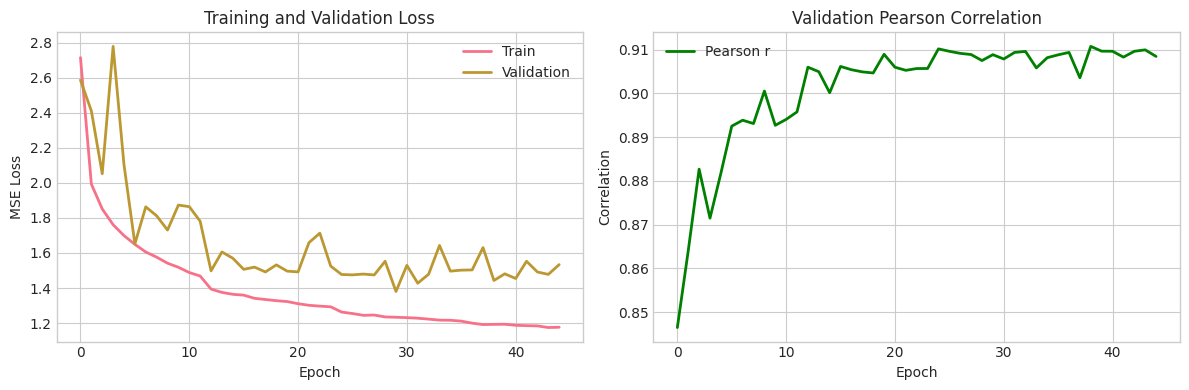

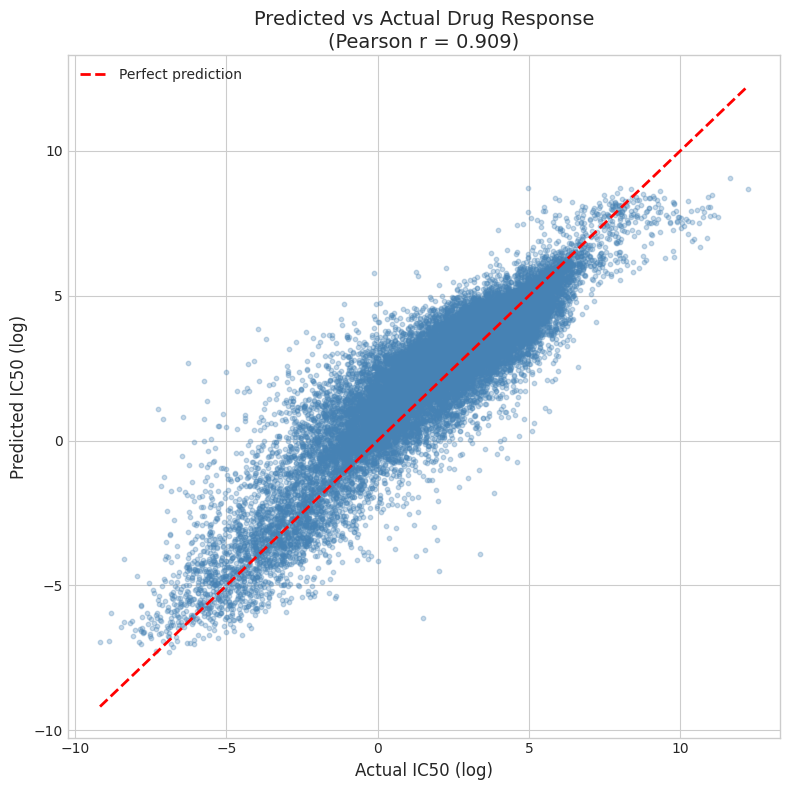

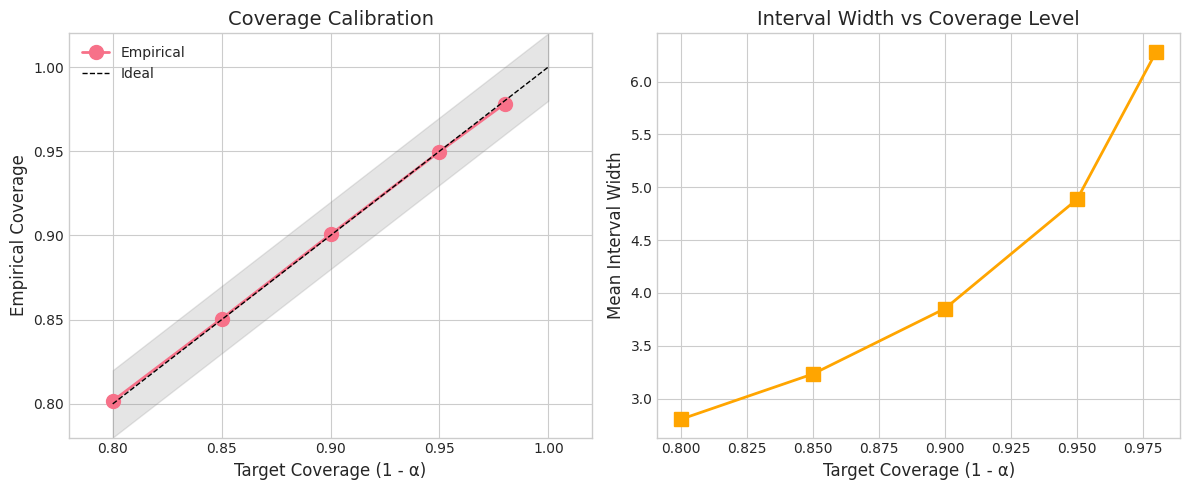

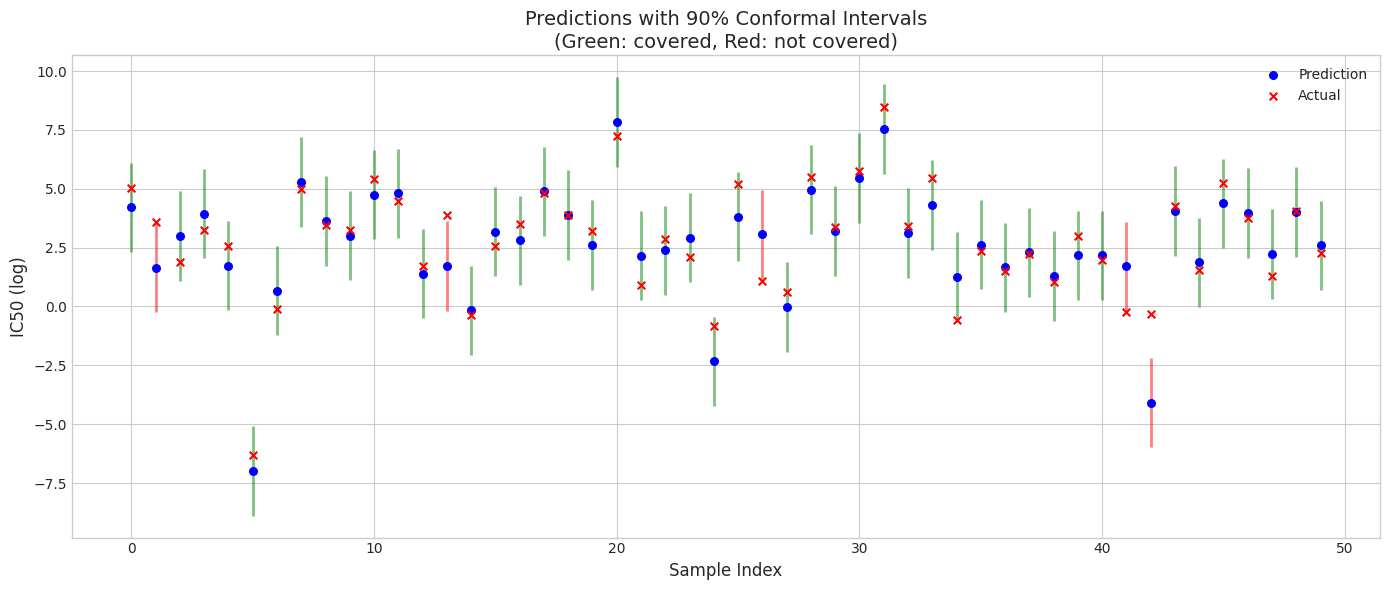

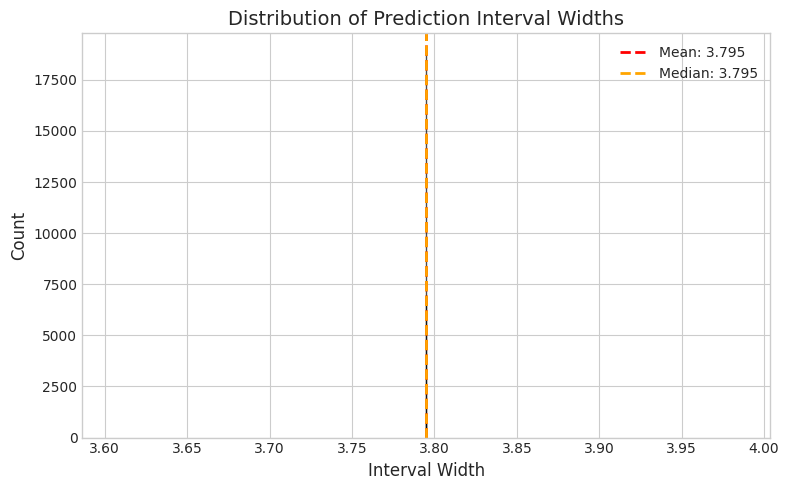

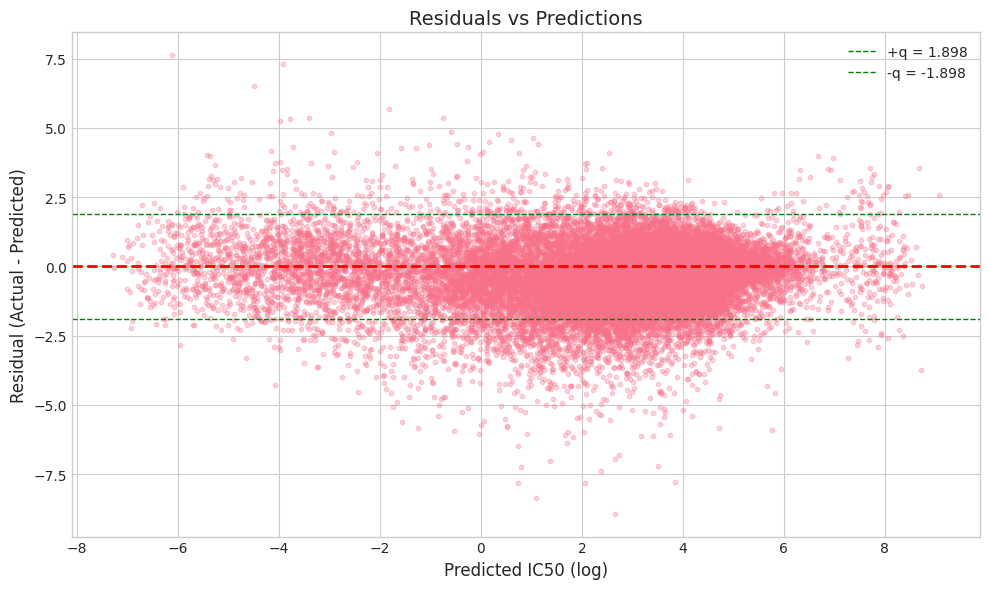


All figures saved to 'figures/' directory


In [14]:
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# Figure 1: Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

axes[1].plot(history['val_pearson'], label='Pearson r', linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Correlation')
axes[1].set_title('Validation Pearson Correlation')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{fig_dir}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# Figure 2: Prediction vs Actual scatter plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(test_results['targets'], test_results['predictions'], 
           alpha=0.3, s=10, c='steelblue')

# Add diagonal line
min_val = min(test_results['targets'].min(), test_results['predictions'].min())
max_val = max(test_results['targets'].max(), test_results['predictions'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual IC50 (log)', fontsize=12)
ax.set_ylabel('Predicted IC50 (log)', fontsize=12)
ax.set_title(f'Predicted vs Actual Drug Response\n(Pearson r = {test_metrics["pearson"]:.3f})', fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig(f'{fig_dir}/prediction_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


# Figure 3: Coverage vs Alpha
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Coverage plot
ax1 = axes[0]
ax1.plot(coverage_df['target_coverage'], coverage_df['empirical_coverage'], 
         'o-', markersize=10, linewidth=2, label='Empirical')
ax1.plot([0.8, 1.0], [0.8, 1.0], 'k--', linewidth=1, label='Ideal')
ax1.fill_between([0.8, 1.0], [0.78, 0.98], [0.82, 1.02], alpha=0.2, color='gray')
ax1.set_xlabel('Target Coverage (1 - α)', fontsize=12)
ax1.set_ylabel('Empirical Coverage', fontsize=12)
ax1.set_title('Coverage Calibration', fontsize=14)
ax1.legend()
ax1.set_xlim(0.78, 1.02)
ax1.set_ylim(0.78, 1.02)

# Interval width plot
ax2 = axes[1]
ax2.plot(coverage_df['target_coverage'], coverage_df['interval_width'], 
         's-', markersize=10, linewidth=2, color='orange')
ax2.set_xlabel('Target Coverage (1 - α)', fontsize=12)
ax2.set_ylabel('Mean Interval Width', fontsize=12)
ax2.set_title('Interval Width vs Coverage Level', fontsize=14)

plt.tight_layout()
plt.savefig(f'{fig_dir}/coverage_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


# Figure 4: Sample predictions with intervals
fig, ax = plt.subplots(figsize=(14, 6))

# Select random samples to visualize
n_samples_to_show = 50
indices = np.random.choice(len(test_results['predictions']), n_samples_to_show, replace=False)
indices = np.sort(indices)

x_pos = np.arange(n_samples_to_show)

# Plot intervals
for i, idx in enumerate(indices):
    color = 'green' if (test_results['targets'][idx] >= test_results['lower'][idx] and 
                        test_results['targets'][idx] <= test_results['upper'][idx]) else 'red'
    ax.vlines(i, test_results['lower'][idx], test_results['upper'][idx], 
              colors=color, alpha=0.5, linewidth=2)

# Plot predictions and actuals
ax.scatter(x_pos, test_results['predictions'][indices], 
           c='blue', s=30, label='Prediction', zorder=3)
ax.scatter(x_pos, test_results['targets'][indices], 
           c='red', s=30, marker='x', label='Actual', zorder=3)

ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('IC50 (log)', fontsize=12)
ax.set_title(f'Predictions with {100*(1-ALPHA):.0f}% Conformal Intervals\n'
             f'(Green: covered, Red: not covered)', fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig(f'{fig_dir}/prediction_intervals.png', dpi=150, bbox_inches='tight')
plt.show()


# Figure 5: Distribution of interval widths
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(test_results['interval_width'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(test_metrics['mean_interval_width'], color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {test_metrics["mean_interval_width"]:.3f}')
ax.axvline(test_metrics['median_interval_width'], color='orange', linestyle='--', 
           linewidth=2, label=f'Median: {test_metrics["median_interval_width"]:.3f}')

ax.set_xlabel('Interval Width', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Prediction Interval Widths', fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig(f'{fig_dir}/interval_width_dist.png', dpi=150, bbox_inches='tight')
plt.show()


# Figure 6: Residuals vs Predictions
fig, ax = plt.subplots(figsize=(10, 6))

residuals = test_results['targets'] - test_results['predictions']
ax.scatter(test_results['predictions'], residuals, alpha=0.3, s=10)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.axhline(cp.quantile, color='green', linestyle='--', linewidth=1, label=f'+q = {cp.quantile:.3f}')
ax.axhline(-cp.quantile, color='green', linestyle='--', linewidth=1, label=f'-q = {-cp.quantile:.3f}')

ax.set_xlabel('Predicted IC50 (log)', fontsize=12)
ax.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
ax.set_title('Residuals vs Predictions', fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig(f'{fig_dir}/residuals.png', dpi=150, bbox_inches='tight')
plt.show()


print(f"\nAll figures saved to '{fig_dir}/' directory")

### Comparison with baseline (No UQ)

In [15]:
print("\n" + "="*60)
print("COMPARISON: WITH VS WITHOUT UNCERTAINTY QUANTIFICATION")
print("="*60)

comparison_table = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'Pearson r', 'Spearman r', 
               'Coverage (90%)', 'Mean Interval Width'],
    'GNN (No UQ)': [
        f"{test_metrics['rmse']:.4f}",
        f"{test_metrics['mae']:.4f}",
        f"{test_metrics['pearson']:.4f}",
        f"{test_metrics['spearman']:.4f}",
        "N/A",
        "N/A"
    ],
    'GNN + Conformal': [
        f"{test_metrics['rmse']:.4f}",
        f"{test_metrics['mae']:.4f}",
        f"{test_metrics['pearson']:.4f}",
        f"{test_metrics['spearman']:.4f}",
        f"{test_metrics['coverage']:.1%}",
        f"{test_metrics['mean_interval_width']:.4f}"
    ]
})

print("\nResults Summary:")
print(comparison_table.to_string(index=False))


COMPARISON: WITH VS WITHOUT UNCERTAINTY QUANTIFICATION

Results Summary:
             Metric GNN (No UQ) GNN + Conformal
               RMSE      1.1844          1.1844
                MAE      0.8756          0.8756
          Pearson r      0.9094          0.9094
         Spearman r      0.8886          0.8886
     Coverage (90%)         N/A           90.2%
Mean Interval Width         N/A          3.7951


### Save results

In [16]:
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Save metrics
metrics_df = pd.DataFrame([test_metrics])
metrics_df.to_csv(f'{results_dir}/test_metrics.csv', index=False)

# Save coverage analysis
coverage_df.to_csv(f'{results_dir}/coverage_analysis.csv', index=False)

# Save predictions
predictions_df = pd.DataFrame({
    'target': test_results['targets'],
    'prediction': test_results['predictions'],
    'lower_bound': test_results['lower'],
    'upper_bound': test_results['upper'],
    'interval_width': test_results['interval_width'],
    'covered': (test_results['targets'] >= test_results['lower']) & 
               (test_results['targets'] <= test_results['upper'])
})
predictions_df.to_csv(f'{results_dir}/predictions.csv', index=False)

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'drug_input_dim': DRUG_INPUT_DIM,
        'n_cell_lines': N_GENES,
        'hidden_dim': HIDDEN_DIM,
        'n_gnn_layers': N_GNN_LAYERS,
        'dropout': DROPOUT
    },
    'conformal_quantile': cp.quantile,
    'alpha': ALPHA
}, f'{results_dir}/model_checkpoint.pt')

print(f"Results saved to '{results_dir}/' directory")
print(f"  - test_metrics.csv")
print(f"  - coverage_analysis.csv")
print(f"  - predictions.csv")
print(f"  - model_checkpoint.pt")


SAVING RESULTS
Results saved to 'results/' directory
  - test_metrics.csv
  - coverage_analysis.csv
  - predictions.csv
  - model_checkpoint.pt


### Final summary

In [17]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"""
Project: GNN + Conformal Prediction for Cancer Drug Response

Dataset: GDSC1 (Genomics of Drug Sensitivity in Cancer)
  - Training samples: {len(train_dataset)}
  - Calibration samples: {len(cal_dataset)}
  - Test samples: {len(test_dataset)}
  - Unique drugs: {len(drug_to_graph)}
  - Unique cell lines: {n_cell_lines}

Model: Graph Neural Network
  - Drug encoder: {N_GNN_LAYERS}-layer GCN with residual connections
  - Cell encoder: MLP on {N_GENES} gene expression features
  - Hidden dimension: {HIDDEN_DIM}
  - Total parameters: {n_params:,}

Conformal Prediction:
  - Method: Split Conformal Prediction
  - α (miscoverage rate): {ALPHA}
  - Calibrated quantile (q): {cp.quantile:.4f}

Test Results:
  - Prediction RMSE: {test_metrics['rmse']:.4f}
  - Prediction MAE: {test_metrics['mae']:.4f}
  - Pearson correlation: {test_metrics['pearson']:.4f}
  - Spearman correlation: {test_metrics['spearman']:.4f}
  - Coverage ({100*(1-ALPHA):.0f}% target): {test_metrics['coverage']:.1%}
  - Mean interval width: {test_metrics['mean_interval_width']:.4f}

Coverage Guarantee: {'✓ SATISFIED' if test_metrics['coverage'] >= (1-ALPHA-0.02) else '✗ NOT SATISFIED'}
""")


FINAL SUMMARY

Project: GNN + Conformal Prediction for Cancer Drug Response

Dataset: GDSC1 (Genomics of Drug Sensitivity in Cancer)
  - Training samples: 124117
  - Calibration samples: 26596
  - Test samples: 26597
  - Unique drugs: 208
  - Unique cell lines: 958

Model: Graph Neural Network
  - Drug encoder: 3-layer GCN with residual connections
  - Cell encoder: MLP on 17737 gene expression features
  - Hidden dimension: 128
  - Total parameters: 4,708,353

Conformal Prediction:
  - Method: Split Conformal Prediction
  - α (miscoverage rate): 0.1
  - Calibrated quantile (q): 1.8975

Test Results:
  - Prediction RMSE: 1.1844
  - Prediction MAE: 0.8756
  - Pearson correlation: 0.9094
  - Spearman correlation: 0.8886
  - Coverage (90% target): 90.2%
  - Mean interval width: 3.7951

Coverage Guarantee: ✓ SATISFIED



### Further Advanced analysis

Conditional coverage by prediction range


CONDITIONAL COVERAGE ANALYSIS

Conditional Coverage by Prediction Range:
 bin         range  coverage  count
   1 [-7.29, 0.80)  0.849436   5320
   2  [0.80, 2.46)  0.858996   5319
   3  [2.46, 3.32)  0.915022   5319
   4  [3.32, 4.22)  0.938334   5319
   5  [4.22, 9.07)  0.950564   5320


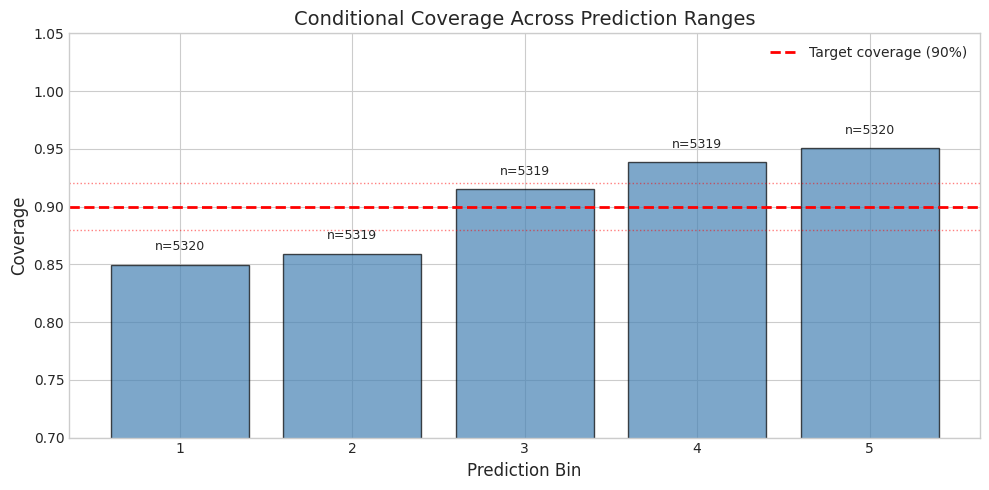

In [18]:
print("\n" + "="*60)
print("CONDITIONAL COVERAGE ANALYSIS")
print("="*60)

def analyze_conditional_coverage(results, n_bins=5):
    """
    Check if coverage is maintained across different prediction ranges.
    Good conformal prediction should have uniform coverage.
    """
    preds = results['predictions']
    targets = results['targets']
    lower = results['lower']
    upper = results['upper']
    
    covered = (targets >= lower) & (targets <= upper)
    
    # Bin by prediction value
    bin_edges = np.percentile(preds, np.linspace(0, 100, n_bins + 1))
    
    conditional_results = []
    for i in range(n_bins):
        mask = (preds >= bin_edges[i]) & (preds < bin_edges[i+1])
        if i == n_bins - 1:  # Include max value in last bin
            mask = (preds >= bin_edges[i]) & (preds <= bin_edges[i+1])
        
        if mask.sum() > 0:
            bin_coverage = covered[mask].mean()
            bin_count = mask.sum()
            conditional_results.append({
                'bin': i + 1,
                'range': f'[{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f})',
                'coverage': bin_coverage,
                'count': bin_count
            })
    
    return pd.DataFrame(conditional_results)

cond_coverage_df = analyze_conditional_coverage(test_results)
print("\nConditional Coverage by Prediction Range:")
print(cond_coverage_df.to_string(index=False))

# Visualize conditional coverage
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(cond_coverage_df['bin'], cond_coverage_df['coverage'], 
              color='steelblue', edgecolor='black', alpha=0.7)
ax.axhline(1 - ALPHA, color='red', linestyle='--', linewidth=2, 
           label=f'Target coverage ({1-ALPHA:.0%})')
ax.axhline((1 - ALPHA) - 0.02, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline((1 - ALPHA) + 0.02, color='red', linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('Prediction Bin', fontsize=12)
ax.set_ylabel('Coverage', fontsize=12)
ax.set_title('Conditional Coverage Across Prediction Ranges', fontsize=14)
ax.set_ylim(0.7, 1.05)
ax.legend()

# Add count labels
for bar, count in zip(bars, cond_coverage_df['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'n={count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{fig_dir}/conditional_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

Error vs. uncertainty analysis


ERROR VS UNCERTAINTY ANALYSIS
Error statistics:
  Mean absolute error: 0.8756
  Median absolute error: 0.6697
  Max absolute error: 8.9233
  Errors within interval: 90.2%


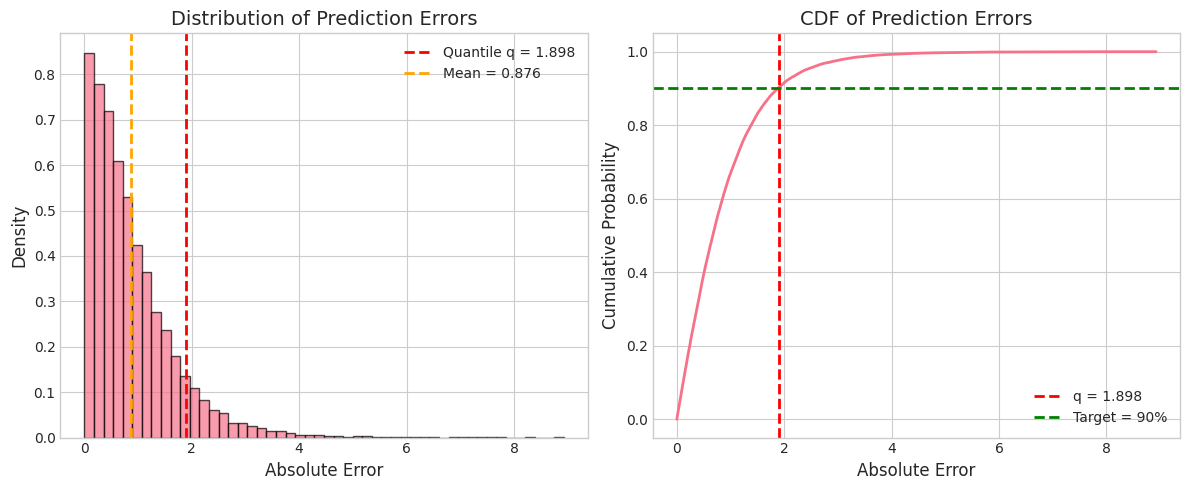

In [19]:
print("\n" + "="*60)
print("ERROR VS UNCERTAINTY ANALYSIS")
print("="*60)

errors = np.abs(test_results['targets'] - test_results['predictions'])

print(f"Error statistics:")
print(f"  Mean absolute error: {errors.mean():.4f}")
print(f"  Median absolute error: {np.median(errors):.4f}")
print(f"  Max absolute error: {errors.max():.4f}")
print(f"  Errors within interval: {(errors <= cp.quantile).mean():.1%}")

# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of errors
ax1 = axes[0]
ax1.hist(errors, bins=50, edgecolor='black', alpha=0.7, density=True)
ax1.axvline(cp.quantile, color='red', linestyle='--', linewidth=2, 
            label=f'Quantile q = {cp.quantile:.3f}')
ax1.axvline(errors.mean(), color='orange', linestyle='--', linewidth=2,
            label=f'Mean = {errors.mean():.3f}')
ax1.set_xlabel('Absolute Error', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribution of Prediction Errors', fontsize=14)
ax1.legend()

# CDF of errors
ax2 = axes[1]
sorted_errors = np.sort(errors)
cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
ax2.plot(sorted_errors, cdf, linewidth=2)
ax2.axvline(cp.quantile, color='red', linestyle='--', linewidth=2,
            label=f'q = {cp.quantile:.3f}')
ax2.axhline(1 - ALPHA, color='green', linestyle='--', linewidth=2,
            label=f'Target = {1-ALPHA:.0%}')
ax2.set_xlabel('Absolute Error', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.set_title('CDF of Prediction Errors', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.savefig(f'{fig_dir}/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Comparison table

In [20]:
print("\n" + "="*60)
print("COMPREHENSIVE RESULTS TABLE")
print("="*60)

results_table = pd.DataFrame({
    'Coverage Level (1-α)': ['80%', '85%', '90%', '95%', '98%'],
    'Target Coverage': coverage_df['target_coverage'].values,
    'Empirical Coverage': coverage_df['empirical_coverage'].values,
    'Coverage Gap': np.abs(coverage_df['target_coverage'] - coverage_df['empirical_coverage']).values,
    'Mean Interval Width': coverage_df['interval_width'].values,
    'Guarantee Met': ['✓' if emp >= tgt - 0.02 else '✗' 
                      for emp, tgt in zip(coverage_df['empirical_coverage'], 
                                         coverage_df['target_coverage'])]
})

print("\nFull Results Table:")
print(results_table.to_string(index=False))

# Save as LaTeX for report
latex_table = results_table.to_latex(index=False, float_format='%.4f')
with open(f'{results_dir}/results_table.tex', 'w') as f:
    f.write(latex_table)
print(f"\nLaTeX table saved to {results_dir}/results_table.tex")


COMPREHENSIVE RESULTS TABLE

Full Results Table:
Coverage Level (1-α)  Target Coverage  Empirical Coverage  Coverage Gap  Mean Interval Width Guarantee Met
                 80%             0.80            0.801745      0.001745             2.804429             ✓
                 85%             0.85            0.850585      0.000585             3.233109             ✓
                 90%             0.90            0.900590      0.000590             3.851797             ✓
                 95%             0.95            0.949731      0.000269             4.885235             ✓
                 98%             0.98            0.978193      0.001807             6.282619             ✓

LaTeX table saved to results/results_table.tex


Combined results figures


GENERATING SUMMARY FIGURES


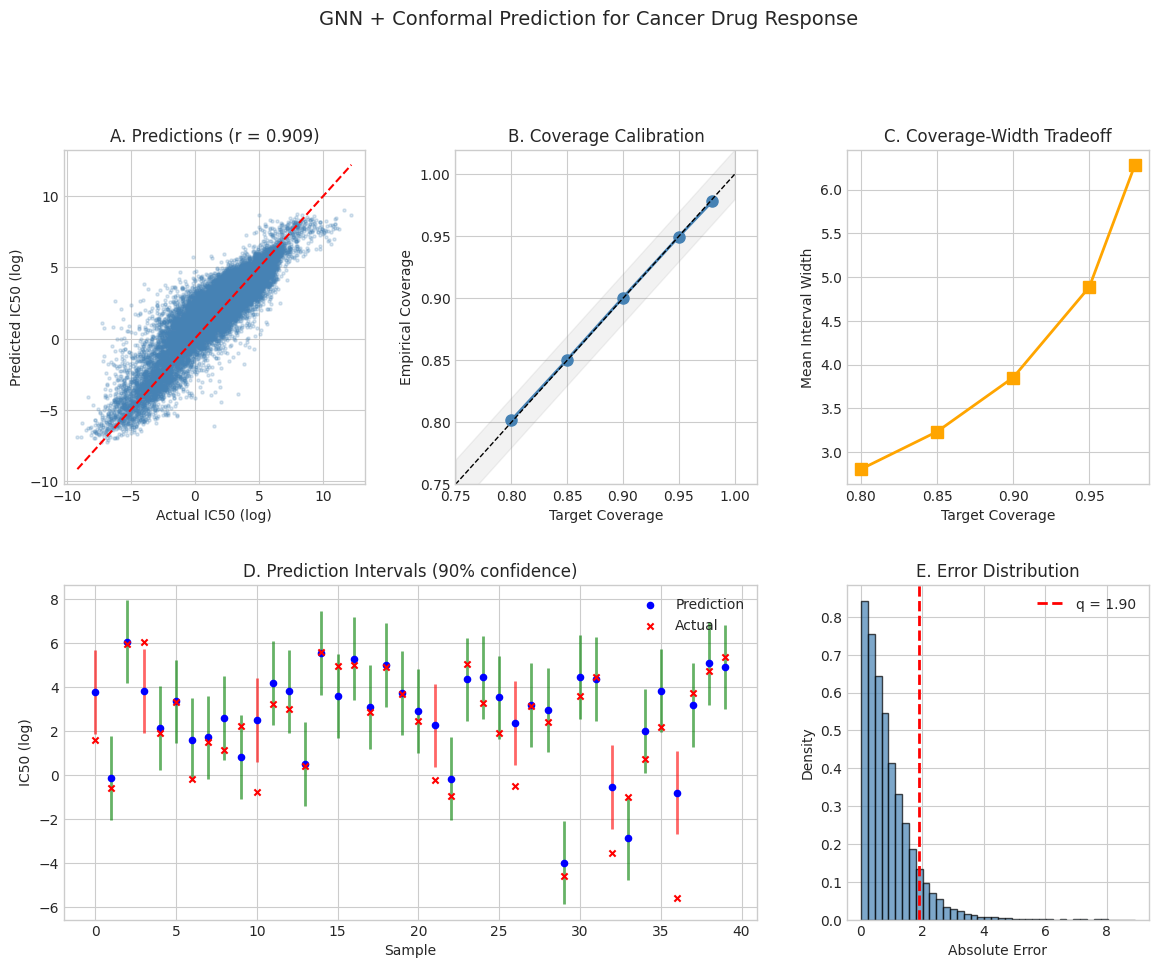


All figures saved!


In [21]:
print("\n" + "="*60)
print("GENERATING SUMMARY FIGURES")
print("="*60)

fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Panel A: Prediction scatter
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(test_results['targets'], test_results['predictions'], 
            alpha=0.2, s=5, c='steelblue')
min_val = min(test_results['targets'].min(), test_results['predictions'].min())
max_val = max(test_results['targets'].max(), test_results['predictions'].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
ax1.set_xlabel('Actual IC50 (log)')
ax1.set_ylabel('Predicted IC50 (log)')
ax1.set_title(f'A. Predictions (r = {test_metrics["pearson"]:.3f})')

# Panel B: Coverage calibration
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(coverage_df['target_coverage'], coverage_df['empirical_coverage'], 
         'o-', markersize=8, linewidth=2, color='steelblue')
ax2.plot([0.75, 1.0], [0.75, 1.0], 'k--', linewidth=1)
ax2.fill_between([0.75, 1.0], [0.73, 0.98], [0.77, 1.02], alpha=0.1, color='gray')
ax2.set_xlabel('Target Coverage')
ax2.set_ylabel('Empirical Coverage')
ax2.set_title('B. Coverage Calibration')
ax2.set_xlim(0.75, 1.02)
ax2.set_ylim(0.75, 1.02)

# Panel C: Interval width vs coverage
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(coverage_df['target_coverage'], coverage_df['interval_width'], 
         's-', markersize=8, linewidth=2, color='orange')
ax3.set_xlabel('Target Coverage')
ax3.set_ylabel('Mean Interval Width')
ax3.set_title('C. Coverage-Width Tradeoff')

# Panel D: Sample intervals
ax4 = fig.add_subplot(gs[1, :2])
n_samples_to_show = 40
indices = np.random.choice(len(test_results['predictions']), n_samples_to_show, replace=False)
indices = np.sort(indices)
x_pos = np.arange(n_samples_to_show)

for i, idx in enumerate(indices):
    covered = (test_results['targets'][idx] >= test_results['lower'][idx] and 
               test_results['targets'][idx] <= test_results['upper'][idx])
    color = 'green' if covered else 'red'
    ax4.vlines(i, test_results['lower'][idx], test_results['upper'][idx], 
               colors=color, alpha=0.6, linewidth=2)

ax4.scatter(x_pos, test_results['predictions'][indices], c='blue', s=20, 
            label='Prediction', zorder=3)
ax4.scatter(x_pos, test_results['targets'][indices], c='red', s=20, 
            marker='x', label='Actual', zorder=3)
ax4.set_xlabel('Sample')
ax4.set_ylabel('IC50 (log)')
ax4.set_title('D. Prediction Intervals (90% confidence)')
ax4.legend(loc='upper right')

# Panel E: Error distribution
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(errors, bins=40, edgecolor='black', alpha=0.7, density=True, color='steelblue')
ax5.axvline(cp.quantile, color='red', linestyle='--', linewidth=2, label=f'q = {cp.quantile:.2f}')
ax5.set_xlabel('Absolute Error')
ax5.set_ylabel('Density')
ax5.set_title('E. Error Distribution')
ax5.legend()

plt.suptitle('GNN + Conformal Prediction for Cancer Drug Response', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{fig_dir}/summary_figure.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{fig_dir}/summary_figure.pdf', bbox_inches='tight')
plt.show()

print(f"\nAll figures saved!")

Statistical tests

In [22]:
print("\n" + "="*60)
print("STATISTICAL ANALYSIS")
print("="*60)

from scipy.stats import binom

n_test = len(test_results['targets'])
n_covered = int(test_metrics['coverage'] * n_test)
target = 1 - ALPHA

# Binomial test
p_value = binom.cdf(n_covered, n_test, target)
if p_value > 0.5:
    p_value = 2 * (1 - p_value)
else:
    p_value = 2 * p_value

print(f"Coverage statistical test:")
print(f"  Null hypothesis: True coverage = {target:.0%}")
print(f"  Observed: {n_covered}/{n_test} = {test_metrics['coverage']:.1%}")
print(f"  P-value (two-tailed): {p_value:.4f}")
print(f"  Conclusion: {'Coverage is as expected' if p_value > 0.05 else 'Coverage differs significantly'}")

from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(test_results['targets'], test_results['predictions'])
spearman_r, spearman_p = spearmanr(test_results['targets'], test_results['predictions'])

print(f"\nCorrelation tests:")
print(f"  Pearson r = {pearson_r:.4f}, p-value = {pearson_p:.2e}")
print(f"  Spearman ρ = {spearman_r:.4f}, p-value = {spearman_p:.2e}")


STATISTICAL ANALYSIS
Coverage statistical test:
  Null hypothesis: True coverage = 90%
  Observed: 24003/26597 = 90.2%
  P-value (two-tailed): 0.1753
  Conclusion: Coverage is as expected

Correlation tests:
  Pearson r = 0.9094, p-value = 0.00e+00
  Spearman ρ = 0.8886, p-value = 0.00e+00


Save everything

In [23]:
# Create summary dictionary
summary = {
    'Dataset': {
        'name': 'GDSC1',
        'source': 'Therapeutics Data Commons (TDC)',
        'n_train': len(train_dataset),
        'n_calibration': len(cal_dataset),
        'n_test': len(test_dataset),
        'n_drugs': len(drug_to_graph),
        'n_cell_lines': n_cell_lines,
        'n_genes': N_GENES  
    },
    'Model': {
        'type': 'GNN (GCN) + Gene Expression MLP',  
        'drug_encoder': 'Graph Convolutional Network',
        'cell_encoder': 'MLP on gene expression',  
        'n_gnn_layers': N_GNN_LAYERS,
        'hidden_dim': HIDDEN_DIM,
        'n_parameters': n_params,
        'dropout': DROPOUT
    },
    'Conformal_Prediction': {
        'method': 'Split Conformal',
        'alpha': ALPHA,
        'quantile': float(cp.quantile)  # Ensure JSON serializable
    },
    'Results': {
        'rmse': float(test_metrics['rmse']),
        'mae': float(test_metrics['mae']),
        'pearson': float(test_metrics['pearson']),
        'spearman': float(test_metrics['spearman']),
        'coverage': float(test_metrics['coverage']),
        'mean_interval_width': float(test_metrics['mean_interval_width'])
    }
}

# Save as JSON
import json
with open(f'{results_dir}/experiment_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Summary saved to {results_dir}/experiment_summary.json")

Summary saved to results/experiment_summary.json


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=81e5ac4f-e423-4ae7-86f3-b21c7a868431' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>